In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
daf = pd.read_csv("/content/drive/MyDrive/Dataset/preprocessing_dataset.csv")
daf1 = daf.copy()

In [ ]:
daf.head(10)

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [ ]:
daf.shape

(10, 5)

In [ ]:
daf.isnull().sum()

,0
Name,0
Age,1
Gender,1
Salary,1
Department,0


In [ ]:
daf.tail()

,Name,Age,Gender,Salary,Department
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [ ]:
daf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        10 non-null     object 
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   Salary      9 non-null      float64
 4   Department  10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


In [ ]:
daf.describe()

,Age,Salary
count,9.000000,9.000000
mean,39.555556,57777.777778
std,30.631320,4521.553322
min,22.000000,50000.000000
25%,27.000000,55000.000000
50%,29.000000,59000.000000
75%,35.000000,61000.000000
max,120.000000,63000.000000


<Axes: >

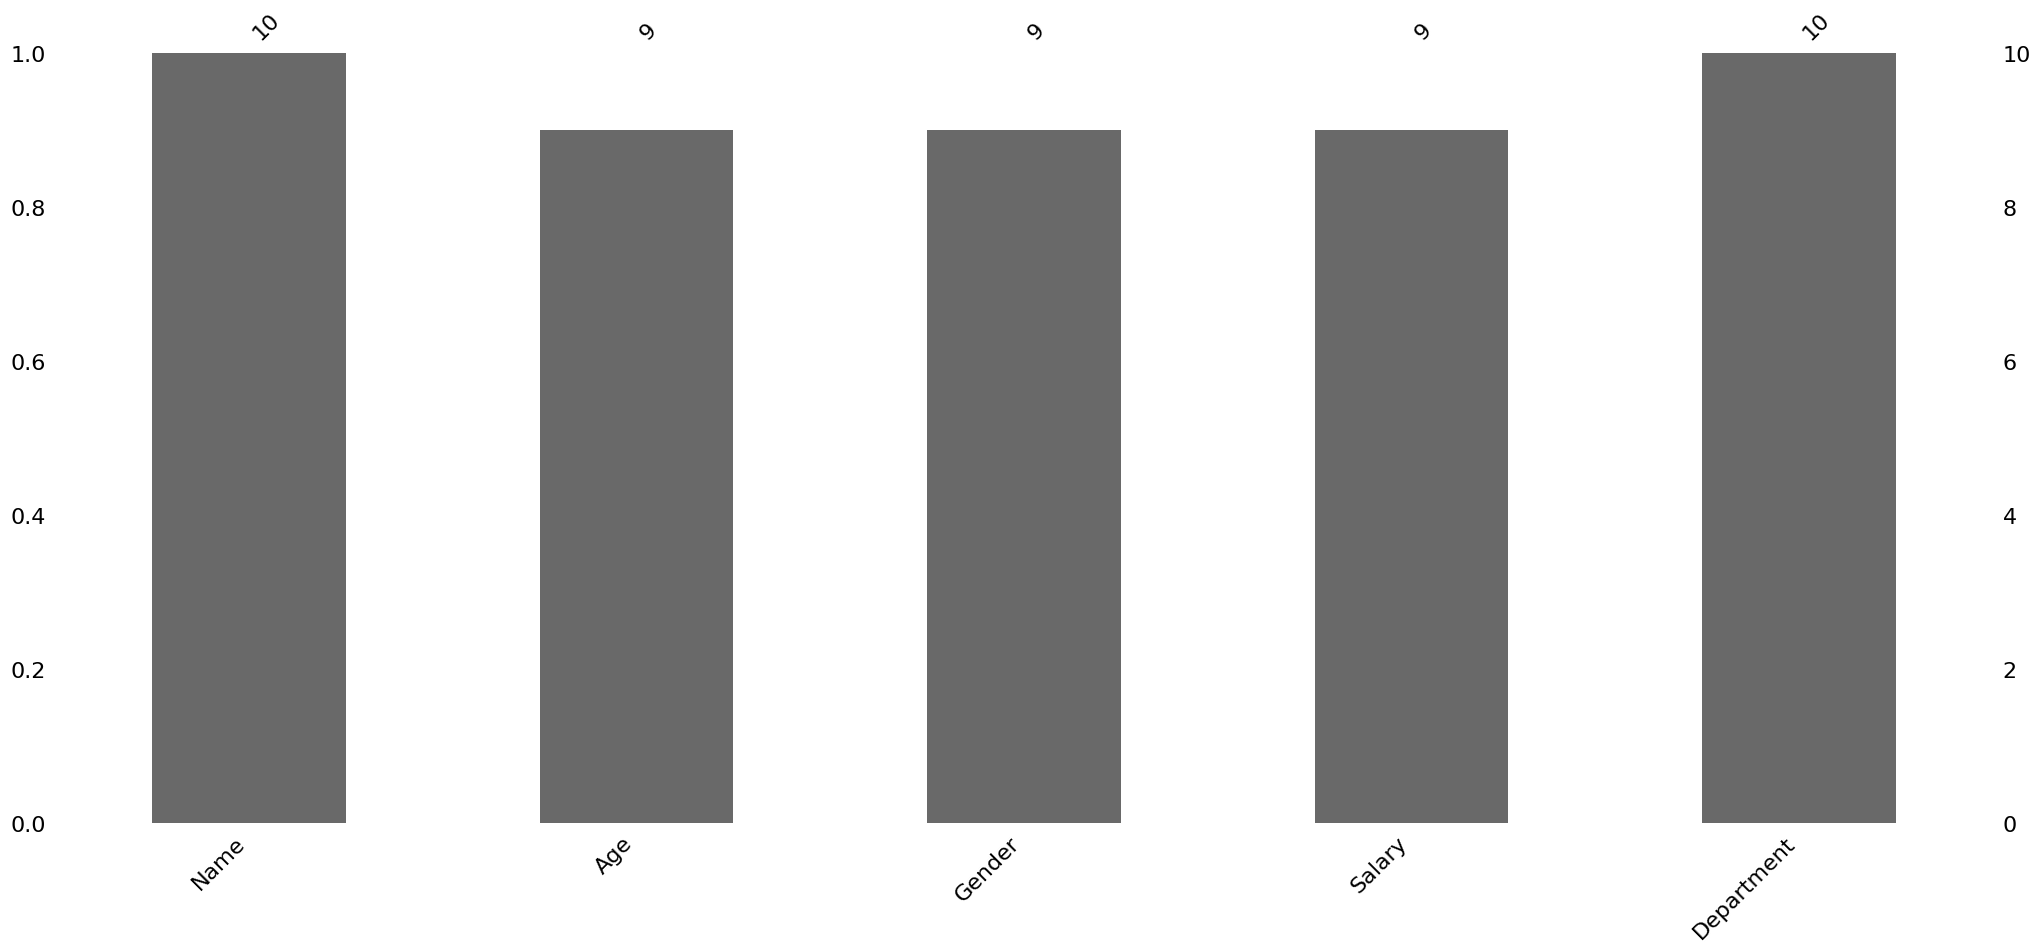

In [ ]:
!pip install missingno
import missingno as msno
msno.bar(daf)

<Axes: >

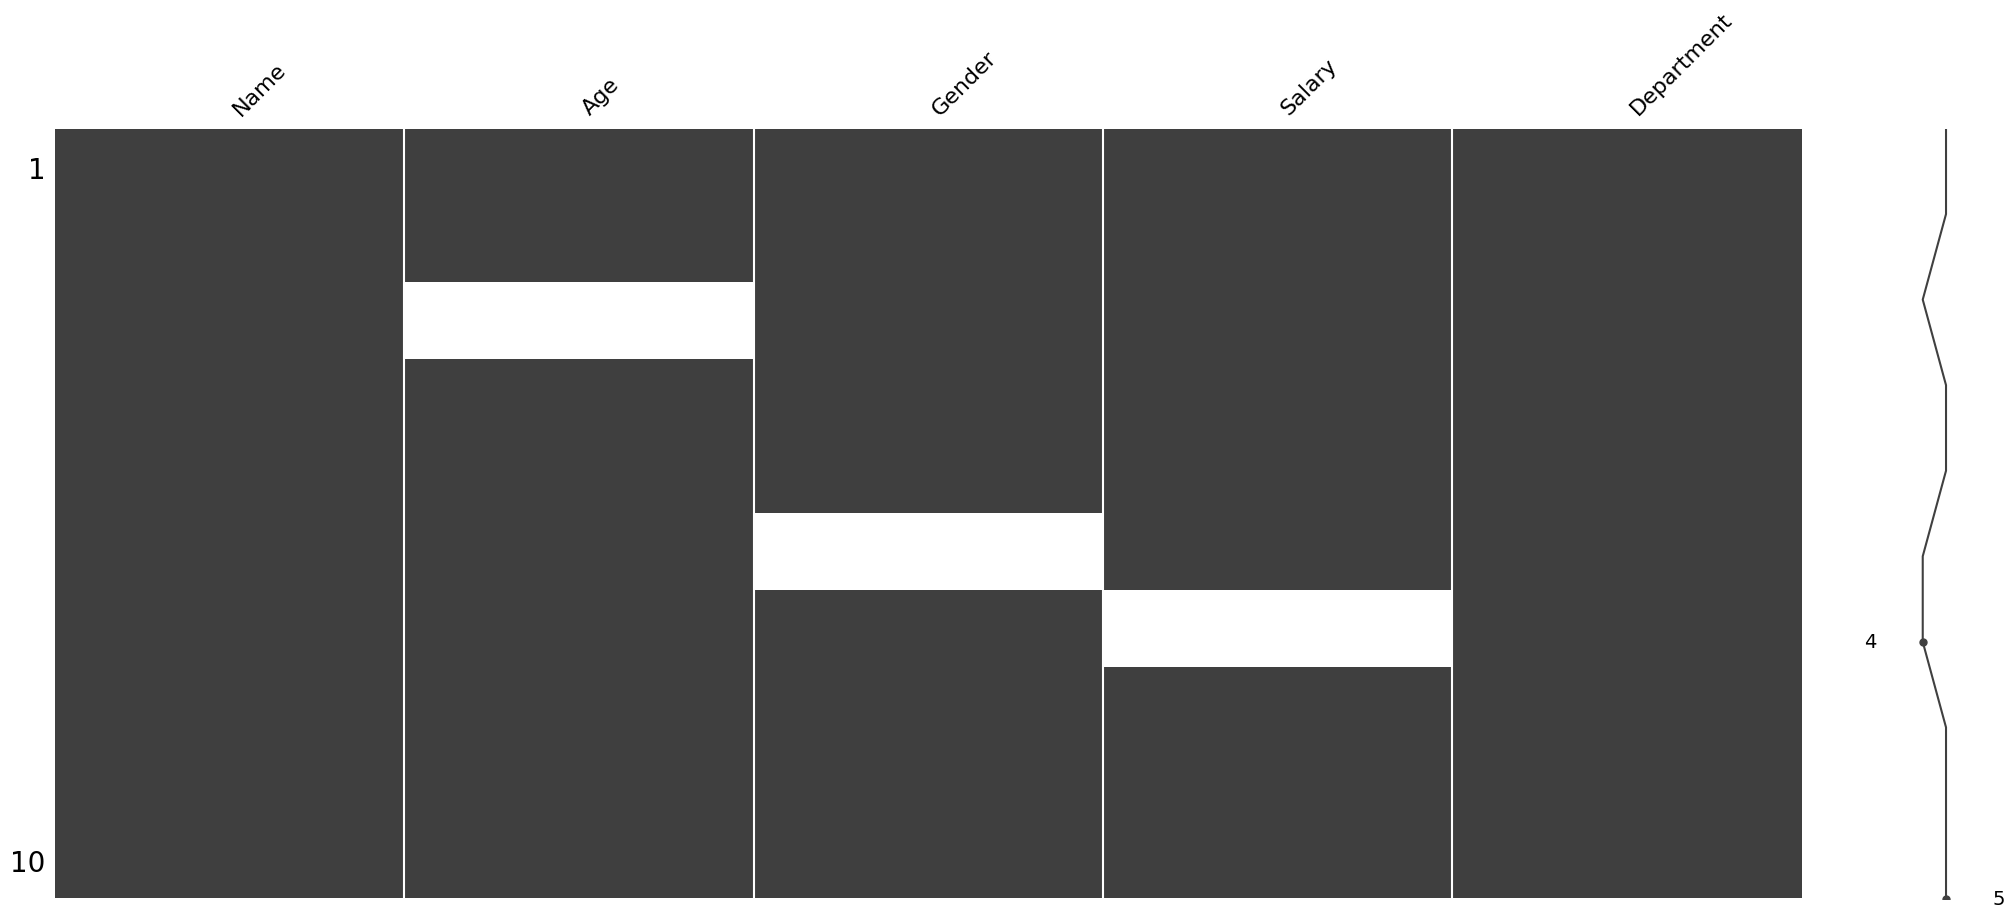

In [ ]:
msno.matrix(daf)

<Axes: >

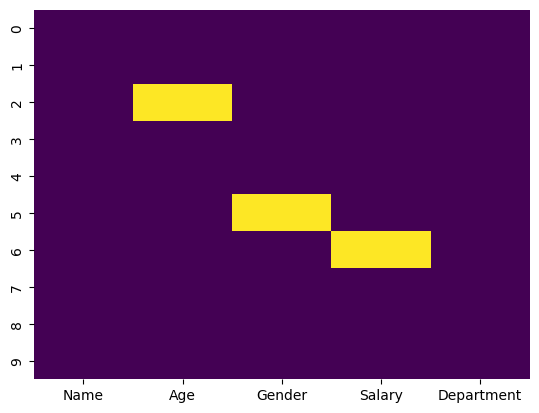

In [ ]:
sns.heatmap(daf.isnull(),cbar=False,cmap='viridis')

In [ ]:
daf['Age'] = daf['Age'].fillna(daf['Age'].mean())#we store as variable or we use inplace
daf['Salary'].fillna(daf['Salary'].mean(),inplace = True)
daf['Gender'].fillna(daf['Gender'].mode()[0],inplace = True)
daf

/tmp/ipykernel_2815/3401801693.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  daf['Salary'].fillna(daf['Salary'].mean(),inplace = True)
/tmp/ipykernel_2815/3401801693.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

,Name,Age,Gender,Salary,Department
0,Alice,25.000000,F,50000.000000,HR
1,Bob,30.000000,M,60000.000000,Finance
2,Charlie,39.555556,M,55000.000000,IT
3,David,40.000000,M,58000.000000,HR
4,Eve,22.000000,F,52000.000000,IT
5,Frank,35.000000,M,61000.000000,Finance
6,Grace,120.000000,F,57777.777778,Finance
7,Henry,28.000000,M,59000.000000,HR
8,Ivy,29.000000,F,63000.000000,IT
9,Jack,27.000000,M,62000.000000,Finance


In [ ]:
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy='median')
daf1[['Age']] = imp.fit_transform(daf1[['Age']])
daf1

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,29.0,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


<Axes: >

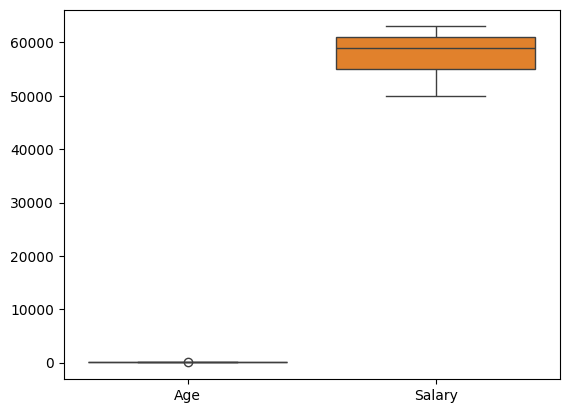

In [ ]:
sns.boxplot(daf1)

<Axes: ylabel='Age'>

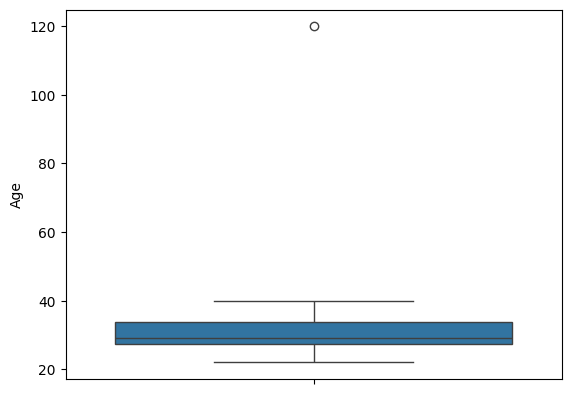

In [ ]:
sns.boxplot(daf1['Age'])

In [ ]:
Q1 = daf['Age'].quantile(0.25)
Q3 = daf['Age'].quantile(0.75)
IQR = Q3 - Q1

lowerbound = Q1-1.5*IQR
upperbound = Q3+1.5*IQR

outlier = daf[(daf['Age'] < lowerbound) | (daf['Age'] > upperbound)]

print(outlier)

    Name    Age Gender  Salary Department
6  Grace  120.0      F     NaN    Finance


In [ ]:
from scipy.stats import zscore

z_scores = zscore(daf1['Age'])
daf1[np.abs(z_scores)>2.5]

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,NaN,Finance


In [ ]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.5)
daf1['outlier'] = iso.fit_predict(daf1[['Age','Salary']])

daf1[daf1['outlier'] == -1]

,Name,Age,Gender,Salary,Department,outlier
0,Alice,25.0,F,50000.0,HR,-1
2,Charlie,29.0,M,55000.0,IT,-1
3,David,40.0,M,58000.0,HR,-1
4,Eve,22.0,F,52000.0,IT,-1
6,Grace,120.0,F,NaN,Finance,-1


In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
daf1['Gender_Encoder'] = le.fit_transform(daf1['Gender'])
daf1

,Name,Age,Gender,Salary,Department,outlier,Gender_Encoder
0,Alice,25.0,F,50000.0,HR,-1,0
1,Bob,30.0,M,60000.0,Finance,1,1
2,Charlie,29.0,M,55000.0,IT,-1,1
3,David,40.0,M,58000.0,HR,-1,1
4,Eve,22.0,F,52000.0,IT,-1,0
5,Frank,35.0,NaN,61000.0,Finance,1,2
6,Grace,120.0,F,NaN,Finance,-1,0
7,Henry,28.0,M,59000.0,HR,1,1
8,Ivy,29.0,F,63000.0,IT,1,0
9,Jack,27.0,M,62000.0,Finance,1,1


In [32]:
from sklearn.preprocessing import OneHotEncoder
one = OneHotEncoder(sparse_output=False)
daf1['Gender'] = one.fit_transform(daf1[['Gender']])
daf1

,Name,Age,Gender,Salary,Department,outlier,Gender_Encoder
0,Alice,25.0,1.0,50000.0,HR,-1,0
1,Bob,30.0,0.0,60000.0,Finance,1,1
2,Charlie,29.0,0.0,55000.0,IT,-1,1
3,David,40.0,0.0,58000.0,HR,-1,1
4,Eve,22.0,1.0,52000.0,IT,-1,0
5,Frank,35.0,0.0,61000.0,Finance,1,2
6,Grace,120.0,1.0,NaN,Finance,-1,0
7,Henry,28.0,0.0,59000.0,HR,1,1
8,Ivy,29.0,1.0,63000.0,IT,1,0
9,Jack,27.0,0.0,62000.0,Finance,1,1


In [33]:
df = pd.get_dummies(daf,columns=['Gender'],drop_first=True)
df

,Name,Age,Salary,Department,outlier,Gender_M
0,Alice,25.0,50000.0,HR,-1,False
1,Bob,30.0,60000.0,Finance,1,True
2,Charlie,NaN,55000.0,IT,-1,True
3,David,40.0,58000.0,HR,-1,True
4,Eve,22.0,52000.0,IT,-1,False
5,Frank,35.0,61000.0,Finance,1,False
6,Grace,120.0,NaN,Finance,-1,False
7,Henry,28.0,59000.0,HR,1,True
8,Ivy,29.0,63000.0,IT,1,False
9,Jack,27.0,62000.0,Finance,1,True
